In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd

# 修正路徑以包含 MyDrive
file_path = '/content/drive/MyDrive/Colab Notebooks/dataset/ParkingRemainDataset.csv'

try:
    df = pd.read_csv(file_path)
    print("成功讀取資料！前五行如下：")
    display(df.head())
except FileNotFoundError:
    print(f"找不到檔案：{file_path}，請確認路徑是否正確。")
except Exception as e:
    print(f"發生錯誤：{e}")

成功讀取資料！前五行如下：


,CollectedAt,IsHoliday,ParkId,TotalSpaces,AvailableSpaces,FullStatus,ParkDataCollectTime,RainNow,RainPast10Min,RainPast1hr,RainPast3hr,RainPast12hr,RainPast24hr
0,2026-05-29T14:23:28,0,1,1998,569,0,2026-05-29T22:21:42+08:00,16.5,0.0,0.0,0.0,1.5,16.5
1,2026-05-29T14:23:28,0,2,446,327,0,2026-05-29T22:21:42+08:00,16.5,0.0,0.0,0.0,1.5,16.5
2,2026-05-29T14:23:28,0,3,169,24,0,2026-05-29T22:21:49+08:00,16.5,0.0,0.0,0.0,1.5,16.5
3,2026-05-29T14:23:28,0,5,204,18,0,2026-05-29T22:21:48+08:00,16.5,0.0,0.0,0.0,1.5,16.5
4,2026-05-29T14:23:28,0,7,508,42,0,2026-05-29T22:21:53+08:00,16.5,0.0,0.0,0.0,1.5,16.5


In [ ]:
# 檢查欄位資訊與資料型態
print("--- 欄位資訊 ---")
df.info()

# 檢查缺失值
print("\n--- 缺失值統計 ---")
print(df.isnull().sum())

--- 欄位資訊 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18080 entries, 0 to 18079
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CollectedAt          18080 non-null  object 
 1   IsHoliday            18080 non-null  int64  
 2   ParkId               18080 non-null  int64  
 3   TotalSpaces          18080 non-null  int64  
 4   AvailableSpaces      18080 non-null  int64  
 5   FullStatus           18080 non-null  int64  
 6   ParkDataCollectTime  18080 non-null  object 
 7   RainNow              18080 non-null  float64
 8   RainPast10Min        18080 non-null  float64
 9   RainPast1hr          18080 non-null  float64
 10  RainPast3hr          18080 non-null  float64
 11  RainPast12hr         18080 non-null  float64
 12  RainPast24hr         18080 non-null  float64
dtypes: float64(6), int64(5), object(2)
memory usage: 1.8+ MB

--- 缺失值統計 ---
CollectedAt            0
IsHoliday              0
P

### 數值描述性統計
我們使用 `describe()` 函式來查看資料集中數值欄位的統計資訊（如平均值、標準差、最大最小值等），這有助於初步觀察資料是否存在異常值或偏態。

In [ ]:
# 顯示數值欄位的統計資訊
display(df.describe())

,IsHoliday,ParkId,TotalSpaces,AvailableSpaces,FullStatus,RainNow,RainPast10Min,RainPast1hr,RainPast3hr,RainPast12hr,RainPast24hr
count,18080.00000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000
mean,0.30000,169.495575,320.886560,75.881803,0.194690,3.781250,0.084375,0.659375,1.778125,5.637500,10.309375
std,0.45827,236.432587,263.977408,113.434368,0.592871,11.749219,0.345615,3.339428,6.920891,14.776122,20.979355
min,0.00000,1.000000,65.000000,-22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,39.000000,186.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,78.000000,251.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.00000,120.000000,359.000000,90.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.125000,7.500000
max,1.00000,829.000000,1998.000000,1095.000000,2.000000,58.000000,2.000000,32.500000,48.500000,58.000000,98.000000


### 停車場數量統計
為了了解資料集涵蓋的範圍，我們統計 `ParkId` 欄位中的唯一值數量，確認共有多少個不同的停車場資料被納入分析。

In [ ]:
# 統計不重複的停車場數量
unique_parks = df['ParkId'].nunique()
print(f"資料集中共有 {unique_parks} 個不同的停車場。")

資料集中共有 113 個不同的停車場。


### 各停車場資料筆數檢查
我們透過計算每個 `ParkId` 出現的次數，來確認各個停車場的資料筆數是否相同，這對於後續的分析（如時間序列）的一致性非常重要。

In [ ]:
# 檢查每個停車場的資料筆數
park_counts = df['ParkId'].value_counts()
print("各停車場資料筆數統計：")
display(park_counts)

# 檢查是否所有筆數都相同
if park_counts.nunique() == 1:
    print(f"\n所有停車場的資料筆數皆為 {park_counts.iloc[0]} 筆。")
else:
    print(f"\n警告：各停車場的資料筆數不一致，範圍介於 {park_counts.min()} 到 {park_counts.max()} 之間。")

各停車場資料筆數統計：


,count
ParkId,
1,160
2,160
3,160
5,160
7,160
...,...
768,160
783,160
784,160



所有停車場的資料筆數皆為 160 筆。


### 資料相關性分析
我們計算所有數值欄位之間的 Pearson 相關係數，以了解特徵與目標變數 `AvailableSpaces` 之間的關聯。

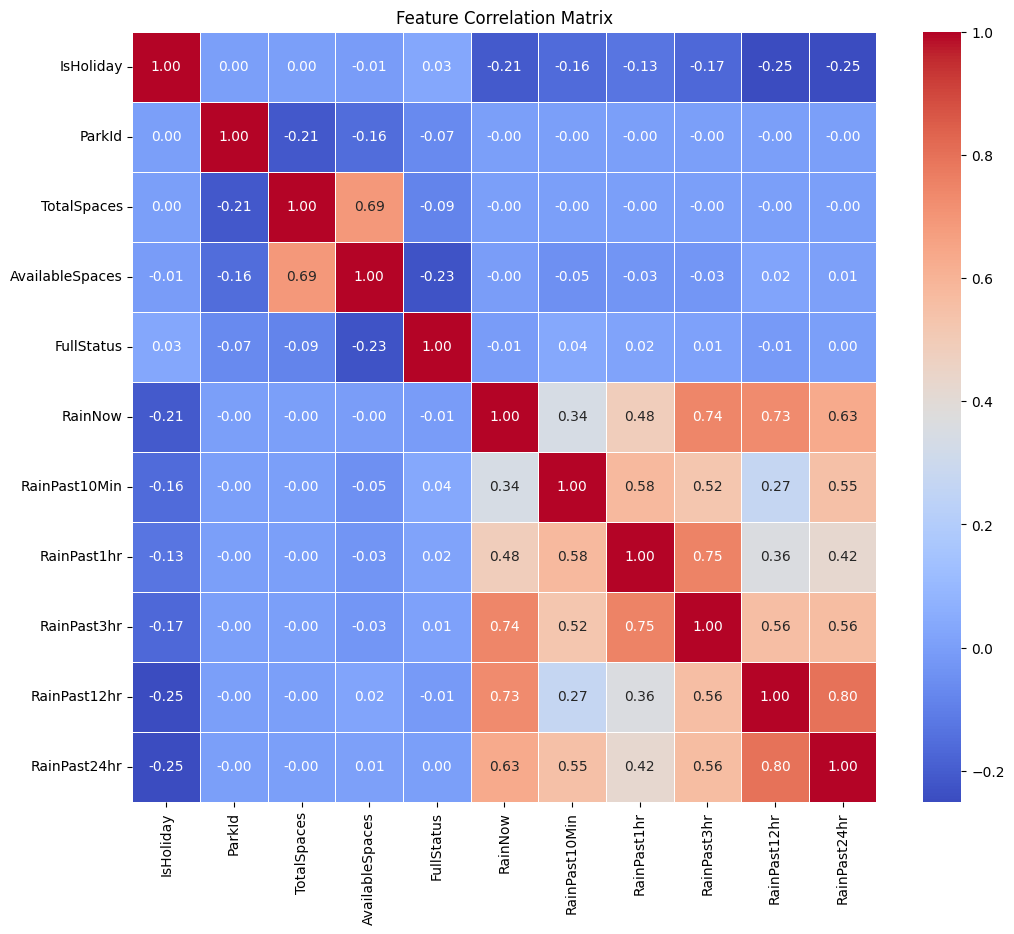

與 AvailableSpaces 的相關性排序：
AvailableSpaces    1.000000
TotalSpaces        0.692151
RainPast12hr       0.021866
RainPast24hr       0.008282
RainNow           -0.003762
IsHoliday         -0.007314
RainPast3hr       -0.030020
RainPast1hr       -0.030897
RainPast10Min     -0.048278
ParkId            -0.155120
FullStatus        -0.225494
Name: AvailableSpaces, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 選擇數值型欄位進行相關性計算
# 排除 CollectedAt (字串) 與原始 ParkDataCollectTime
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# 設定繪圖風格
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# 顯示與 AvailableSpaces 相關性最高的前幾個欄位
print("與 AvailableSpaces 的相關性排序：")
print(corr_matrix['AvailableSpaces'].sort_values(ascending=False))

### 時間特徵工程 (Feature Engineering)
XGBoost 無法直接讀取日期格式。我們需要將 `CollectedAt` 轉換為多個數值欄位（如：小時、星期、月份），這樣模型才能學習到例如「尖峰時段」或「週末與否」對空位影響的規律。

In [ ]:
# 檢查 'ParkDataCollectTime' 欄位是否為原始的 'object' (字串) 類型
# 若是，則進行時間轉換與調整，以確保只執行一次，避免重複累加時差
if pd.api.types.is_object_dtype(df['ParkDataCollectTime']):
    print("Converting 'ParkDataCollectTime' to datetime and applying +8 hour offset...")
    # 將 'ParkDataCollectTime' 轉換為 datetime 格式，並加上 8 小時以校正時區
    # 之後移除時區資訊，使其成為一個本地時間
    df['ParkDataCollectTime'] = pd.to_datetime(df['ParkDataCollectTime']) + pd.Timedelta(hours=8)
    df['ParkDataCollectTime'] = df['ParkDataCollectTime'].dt.tz_localize(None)
elif pd.api.types.is_datetime64_any_dtype(df['ParkDataCollectTime']):
    print("'ParkDataCollectTime' is already datetime type. Skipping +8 hour offset to prevent re-adjustment.")
else:
    print("Warning: 'ParkDataCollectTime' is neither object nor datetime type. No time feature engineering performed for time adjustment.")

# 從調整後（或已調整過）的 'ParkDataCollectTime' 中提取時間特徵
df['Hour'] = df['ParkDataCollectTime'].dt.hour
df['DayOfWeek'] = df['ParkDataCollectTime'].dt.dayofweek
df['Month'] = df['ParkDataCollectTime'].dt.month
df['Day'] = df['ParkDataCollectTime'].dt.day

# 檢查轉換後的新欄位
print("使用修正後（+8小時且移除時區標示）的 ParkDataCollectTime 提取的時間特徵：")
display(df[['ParkDataCollectTime', 'Hour', 'DayOfWeek', 'Month', 'Day']].head())

Converting 'ParkDataCollectTime' to datetime and applying +8 hour offset...
使用修正後（+8小時且移除時區標示）的 ParkDataCollectTime 提取的時間特徵：


,ParkDataCollectTime,Hour,DayOfWeek,Month,Day
0,2026-05-30 06:21:42,6,5,5,30
1,2026-05-30 06:21:42,6,5,5,30
2,2026-05-30 06:21:49,6,5,5,30
3,2026-05-30 06:21:48,6,5,5,30
4,2026-05-30 06:21:53,6,5,5,30


### 資料清洗：處理可用車位負值
在某些情況下，系統紀錄可能出現負數的可用車位。我們將這些異常值統一修正為 0。

In [ ]:
# 檢查轉換前的負值數量
negative_count = (df['AvailableSpaces'] < 0).sum()
print(f"修正前 AvailableSpaces 中的負值筆數: {negative_count}")

# 將負值轉換為 0
df.loc[df['AvailableSpaces'] < 0, 'AvailableSpaces'] = 0

# 驗證轉換結果
print(f"修正後 AvailableSpaces 中的負值筆數: {(df['AvailableSpaces'] < 0).sum()}")
display(df['AvailableSpaces'].describe())

修正前 AvailableSpaces 中的負值筆數: 166
修正後 AvailableSpaces 中的負值筆數: 0


,AvailableSpaces
count,18080.000000
mean,76.077102
std,113.284562
min,0.000000
25%,15.000000
50%,42.000000
75%,90.000000
max,1095.000000


### LSTM 模型建立與訓練 (Time Series Data Preparation)
LSTM 模型需要將時間序列資料轉換為特定格式（例如：序列化輸入）。我們將針對每個停車場，建立過去時間點的觀測值作為預測未來空位數的輸入特徵。

**資料準備步驟：**
1.  **特徵選擇**：選擇對預測有用的數值特徵。
2.  **資料標準化**：由於 LSTM 對輸入值的尺度敏感，我們需要對特徵進行標準化。
3.  **序列化資料**：為每個停車場建立滑動窗口，將過去 `n_steps` 個時間步的資料作為輸入序列 (X)，將第 `n_steps+1` 個時間步的 `AvailableSpaces` 作為目標 (y)。

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 選擇用於 LSTM 的特徵
lstm_features = ['TotalSpaces', 'AvailableSpaces', 'IsHoliday', 'RainNow', 'RainPast10Min',
                 'RainPast1hr', 'RainPast3hr', 'RainPast12hr', 'RainPast24hr',
                 'Hour', 'DayOfWeek', 'Month', 'Day']

# 為了避免數據洩漏，我們針對每個ParkId進行獨立的數據處理
# 但由於數據量較小且時間序列較短，這裡先進行整體數據的標準化
# 如果數據量大且時間序列長，應在序列化後再做按序列的標準化

# 複製一份 DataFrame 以免修改原始 df
df_lstm = df.copy()

# 針對每個ParkId，按時間排序
df_lstm = df_lstm.sort_values(by=['ParkId', 'ParkDataCollectTime'])

# 對選擇的特徵進行標準化 (MinMaxScaler)
scaler = MinMaxScaler(feature_range=(0, 1))
df_lstm[lstm_features] = scaler.fit_transform(df_lstm[lstm_features])

# 顯示標準化後的數據
print("標準化後的數據前五行：")
display(df_lstm[lstm_features].head())

標準化後的數據前五行：


,TotalSpaces,AvailableSpaces,IsHoliday,RainNow,RainPast10Min,RainPast1hr,RainPast3hr,RainPast12hr,RainPast24hr,Hour,DayOfWeek,Month,Day
0,1.0,0.519635,0.0,0.284483,0.0,0.0,0.0,0.025862,0.168367,0.260870,0.833333,0.8,0.966667
113,1.0,0.581735,0.0,0.284483,0.0,0.0,0.0,0.017241,0.168367,0.260870,0.833333,0.8,0.966667
226,1.0,0.810959,0.0,0.284483,0.0,0.0,0.0,0.000000,0.168367,0.304348,0.833333,0.8,0.966667
339,1.0,0.829224,1.0,0.000000,0.0,0.0,0.0,0.000000,0.168367,0.347826,0.833333,0.8,0.966667
452,1.0,0.837443,1.0,0.000000,0.0,0.0,0.0,0.000000,0.168367,0.391304,0.833333,0.8,0.966667


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


### 建立序列數據集 (Sequenced Dataset Creation)
我們將定義一個函數來將時間序列資料轉換為 LSTM 模型所需的序列格式。每個序列將包含 `n_steps` 個時間步的特徵數據作為輸入，以及下一個時間步的 `AvailableSpaces` 作為預測目標。

In [ ]:
from sklearn.model_selection import train_test_split

def create_sequences(data, feature_cols, target_col, n_steps):
    X, y = [], []
    # 確保target_col在feature_cols中，因為我們需要它的索引
    feature_indices = {col: i for i, col in enumerate(feature_cols)}
    target_idx = feature_indices[target_col]

    for i in range(len(data) - n_steps):
        # 提取當前序列的特徵
        seq_x = data[i:(i + n_steps), :]
        X.append(seq_x)
        # 提取下一個時間步的目標值
        seq_y = data[i + n_steps, target_idx]
        y.append(seq_y)
    return np.array(X), np.array(y)

# 設置時間步長
n_steps = 10 # 使用過去10個時間步的數據來預測下一個時間步

# 將 DataFrame 轉換為 NumPy 陣列以便處理
# 這裡將 ParkId 作為分組鍵，然後再處理每個組
X_lstm, y_lstm = [], []

for park_id in df_lstm['ParkId'].unique():
    park_data = df_lstm[df_lstm['ParkId'] == park_id][lstm_features].values
    if len(park_data) >= n_steps + 1: # 確保有足夠的數據來創建序列
        X_park, y_park = create_sequences(park_data, lstm_features, 'AvailableSpaces', n_steps)
        X_lstm.append(X_park)
        y_lstm.append(y_park)

X_lstm = np.vstack(X_lstm)
y_lstm = np.concatenate(y_lstm)

print(f"X_lstm 的形狀: {X_lstm.shape}") # (samples, n_steps, n_features)
print(f"y_lstm 的形狀: {y_lstm.shape}") # (samples,)

# 分割訓練集、驗證集和測試集
# 再次使用 train_test_split，這次是對序列數據進行分割
X_train_lstm, X_temp_lstm, y_train_lstm, y_temp_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)
X_val_lstm, X_test_lstm, y_val_lstm, y_test_lstm = train_test_split(X_temp_lstm, y_temp_lstm, test_size=0.5, random_state=42)

print(f"LSTM 訓練集大小: {X_train_lstm.shape}")
print(f"LSTM 驗證集大小: {X_val_lstm.shape}")
print(f"LSTM 測試集大小: {X_test_lstm.shape}")

X_lstm 的形狀: (16950, 10, 13)
y_lstm 的形狀: (16950,)
LSTM 訓練集大小: (13560, 10, 13)
LSTM 驗證集大小: (1695, 10, 13)
LSTM 測試集大小: (1695, 10, 13)


### 建立與訓練 LSTM 模型
現在我們將定義一個 LSTM 模型，並使用訓練數據進行訓練。模型將包含 LSTM 層、Dropout 層（用於防止過擬合）和 Dense 層（用於輸出預測）。

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# LSTM 模型架構
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(units=50, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units=1)) # 預測單一數值 (AvailableSpaces)

# 編譯模型
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 早停回調函數
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 訓練模型
history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_lstm, y_val_lstm),
    callbacks=[early_stopping],
    verbose=1
)

print("LSTM 模型訓練完成。")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


424/424 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0041 - val_loss: 0.0018
Epoch 2/100
424/424 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0019 - val_loss: 0.0011
Epoch 3/100
424/424 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0013 - val_loss: 7.9423e-04
Epoch 4/100
424/424 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0011 - val_loss: 8.4629e-04
Epoch 5/100
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 8.5027e-04 - val_loss: 4.7971e-04
Epoch 6/100
424/424 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 7.1325e-04 - val_loss: 4.0537e-04
Epoch 7/100
424/424 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 6.2554e-04 - val_loss: 3.9248e-04
Epoch 8/100
424/424 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5.6246e-04 - val_loss: 2.8847e-04
Epoch 9/100
424/424 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5.0390e-04 - val_loss: 2.6050e-04
Epoch 10/100
424/424 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 4.9647e-04 - val_loss: 2.4336e-04
Epoch 11/100
424/424 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 4.6127e-04 -

### 評估 LSTM 模型
訓練完成後，我們將使用測試集來評估 LSTM 模型的性能，計算 RMSE 和 R2 Score。由於預測值是標準化後的，我們需要將其反標準化回原始範圍，才能與原始的 `AvailableSpaces` 進行比較。

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 進行預測
y_pred_lstm_scaled = model_lstm.predict(X_test_lstm)

# 由於模型預測的是標準化後的 'AvailableSpaces'，我們需要將其反標準化
# 為了反標準化 'AvailableSpaces'，我們需要一個包含所有特徵的 "dummy" 陣列
# 因為 scaler.inverse_transform 需要所有原始特徵

# 創建一個全零的陣列，形狀與原始特徵相同
dummy_array = np.zeros((len(y_pred_lstm_scaled), len(lstm_features)))

# 將預測的AvailableSpaces（標準化後）放入正確的欄位索引
target_idx = lstm_features.index('AvailableSpaces')
dummy_array[:, target_idx] = y_pred_lstm_scaled.flatten()

# 反標準化
y_pred_lstm = scaler.inverse_transform(dummy_array)[:, target_idx]

# 同樣地，反標準化實際值 y_test_lstm
dummy_array_true = np.zeros((len(y_test_lstm), len(lstm_features)))
dummy_array_true[:, target_idx] = y_test_lstm.flatten()
y_test_lstm_original = scaler.inverse_transform(dummy_array_true)[:, target_idx]

# 確保預測值不為負
y_pred_lstm = np.maximum(y_pred_lstm, 0)

# 計算評估指標
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_original, y_pred_lstm))
r2_lstm = r2_score(y_test_lstm_original, y_pred_lstm)

print(f"\nLSTM 測試集 RMSE: {rmse_lstm:.2f}")
print(f"LSTM 測試集 R2 Score: {r2_lstm:.4f}")

# 顯示部分預測結果對照
results_lstm = pd.DataFrame({'實際值': y_test_lstm_original, '預測值': y_pred_lstm}).reset_index(drop=True)
display(results_lstm.head(10))

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

LSTM 測試集 RMSE: 14.54
LSTM 測試集 R2 Score: 0.9802


,實際值,預測值
0,279.0,295.503161
1,18.0,12.688705
2,0.0,4.386201
3,59.0,47.719810
4,6.0,5.917873
5,10.0,13.230756
6,8.0,5.759021
7,0.0,3.762582
8,6.0,7.144225
9,35.0,32.035533
